# Customer Churn Prediction - Simple FCNN Model



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')


## 1) قراءة الداتا (Load Data)


In [4]:
Data = pd.read_csv('Churn_Modelling.csv')
Data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
summary = Data.describe()
print(summary)

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

In [7]:
Data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## 2) استكشاف بسيط للداتا (Quick EDA)


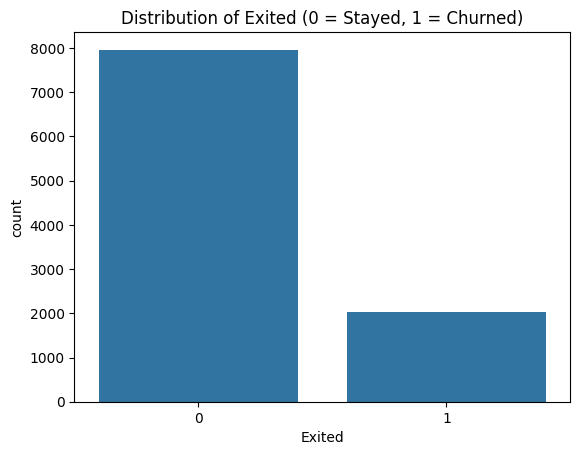

In [8]:
sns.countplot(x='Exited', data=Data)
plt.title('Distribution of Exited (0 = Stayed, 1 = Churned)')
plt.show()

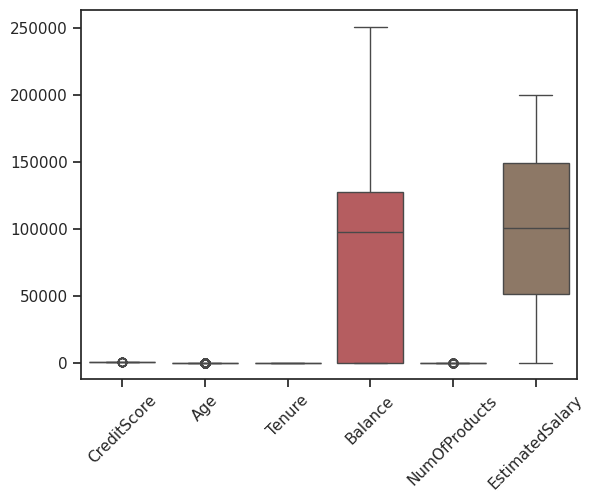

In [9]:
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
sns.set(style="ticks")
sns.boxplot(data=Data[numeric_cols])
plt.xticks(rotation=45)
plt.show()

## 3) تنظيف الداتا وإعداد الأعمدة (Preprocessing)


In [10]:
Data = Data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

Data['Gender'] = Data['Gender'].map({'Male': 1, 'Female': 0})

Data = pd.get_dummies(Data, columns=['Geography'], drop_first=True)

Data.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False


In [11]:
X = Data.drop('Exited', axis=1)
y = Data['Exited']

print('X shape:', X.shape)
print('y shape:', y.shape)
X.columns.tolist()

X shape: (10000, 11)
y shape: (10000,)


['CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain']

## 4) تقسيم الداتا (Train / Test Split)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


## 5) توحيد المقاييس (Feature Scaling)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6) بناء الموديل (Simple FCNN)



In [14]:
n_features = X_train_scaled.shape[1]

model = Sequential()
model.add(Input(shape=(n_features,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## 7) تدريب الموديل (Training)


In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7739 - loss: 0.5345 - val_accuracy: 0.7994 - val_loss: 0.4659
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8011 - loss: 0.4512 - val_accuracy: 0.8081 - val_loss: 0.4338
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8150 - loss: 0.4274 - val_accuracy: 0.8213 - val_loss: 0.4210
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8245 - loss: 0.4150 - val_accuracy: 0.8331 - val_loss: 0.4077
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8286 - loss: 0.4030 - val_accuracy: 0.8369 - val_loss: 0.3946
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8397 - loss: 0.3905 - val_accuracy: 0.8469 - val_loss: 0.3799
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8423 - loss: 0.3783 - val_accuracy: 0.8500 - val_loss: 0.3677
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8467 - loss: 0.3690 - val_accu

## 8) رسم منحنيات التدريب (Loss & Accuracy Curves)

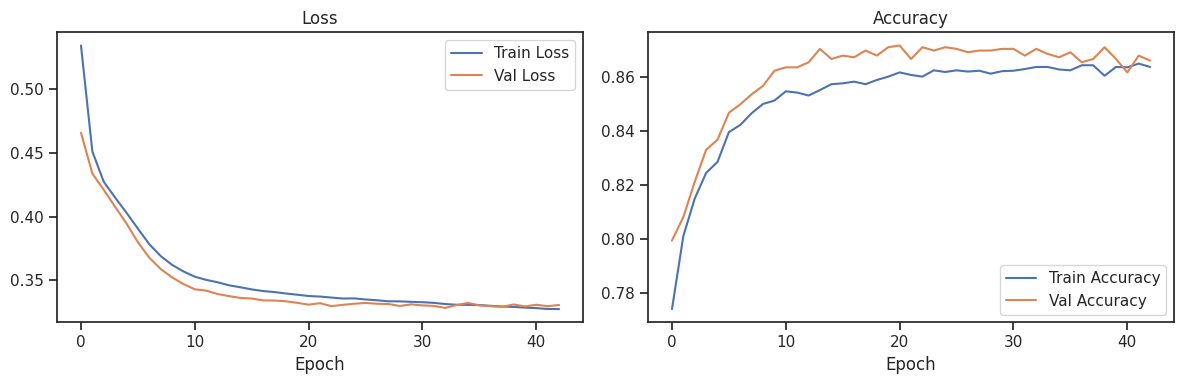

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## 9) تقييم الموديل على داتا الاختبار (Evaluation on Test Data)

In [18]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Test Loss: 0.3322
Test Accuracy: 0.8605
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
[[1536   57]
 [ 222  185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



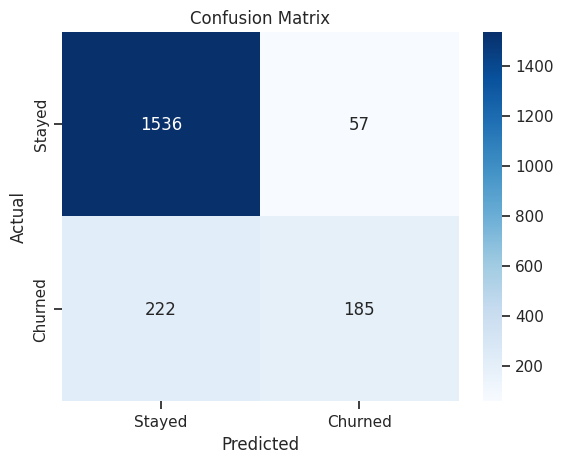

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 10) البحث عن أفضل Hyperparameters (Best Parameters)


In [20]:
def build_model(n_features, units1, units2):
    m = Sequential()
    m.add(Input(shape=(n_features,)))
    m.add(Dense(units1, activation='relu'))
    m.add(Dense(units2, activation='relu'))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

param_grid = [
    {'units1': 8,  'units2': 4,  'batch_size': 16},
    {'units1': 16, 'units2': 8,  'batch_size': 32},
    {'units1': 32, 'units2': 16, 'batch_size': 32},
    {'units1': 32, 'units2': 16, 'batch_size': 64},
    {'units1': 64, 'units2': 32, 'batch_size': 64},
]

results = []
early_stop_search = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

for params in param_grid:
    m = build_model(n_features, params['units1'], params['units2'])
    h = m.fit(
        X_train_scaled, y_train,
        epochs=60,
        batch_size=params['batch_size'],
        validation_split=0.2,
        callbacks=[early_stop_search],
        verbose=0
    )
    val_acc = max(h.history['val_accuracy'])
    results.append({**params, 'val_accuracy': val_acc})
    print(f"units1={params['units1']}, units2={params['units2']}, batch_size={params['batch_size']} -> val_accuracy={val_acc:.4f}")

results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
print('\nBest combination:')
print(results_df.iloc[0])

units1=8, units2=4, batch_size=16 -> val_accuracy=0.8800
units1=16, units2=8, batch_size=32 -> val_accuracy=0.8562
units1=32, units2=16, batch_size=32 -> val_accuracy=0.8712
units1=32, units2=16, batch_size=64 -> val_accuracy=0.8625
units1=64, units2=32, batch_size=64 -> val_accuracy=0.8637

Best combination:
units1           8.00
units2           4.00
batch_size      16.00
val_accuracy     0.88
Name: 0, dtype: float64


## 11) تدريب الموديل النهائي بأفضل Parameters


In [21]:
best_params = results_df.iloc[0]
print('Best parameters found:')
print(best_params)

final_model = build_model(n_features, int(best_params['units1']), int(best_params['units2']))

final_history = final_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=int(best_params['batch_size']),
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Best parameters found:
units1           8.00
units2           4.00
batch_size      16.00
val_accuracy     0.88
Name: 0, dtype: float64
Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7953 - loss: 0.5178 - val_accuracy: 0.8000 - val_loss: 0.4762
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7953 - loss: 0.4636 - val_accuracy: 0.8000 - val_loss: 0.4466
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7953 - loss: 0.4423 - val_accuracy: 0.8000 - val_loss: 0.4363
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7953 - loss: 0.4335 - val_accuracy: 0.8000 - val_loss: 0.4313
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7953 - loss: 0.4279 - val_accuracy: 0.8000 - val_loss: 0.4271
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7953 - loss: 0.4229 - val_accuracy: 0.8000 - val_loss: 0.4215
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7953 - loss: 0.4172 - va

In [22]:
final_loss, final_accuracy = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Final Test Loss: {final_loss:.4f}')
print(f'Final Test Accuracy: {final_accuracy:.4f}')

y_pred_final = (final_model.predict(X_test_scaled) > 0.5).astype(int)
print('\nFinal Classification Report:')
print(classification_report(y_test, y_pred_final))

Final Test Loss: 0.3358
Final Test Accuracy: 0.8645
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.74      0.51      0.60       407

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.86      0.85      2000

